11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 49ms/step - accuracy: 0.9168 - loss: 0.2713 - val_accuracy: 0.9832 - val_loss: 0.0559
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 48ms/step - accuracy: 0.9724 - loss: 0.0941 - val_accuracy: 0.9882 - val_loss: 0.0427
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - accuracy: 0.9795 - loss: 0.0688 - val_accuracy: 0.9895 - val_loss: 0.0350
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - accuracy: 0.9831 - loss: 0.0543 - val_accuracy: 0.9888 - val_loss: 0.0399
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.9853 - loss: 0.0474 - val_accuracy: 0.9912 - val_loss: 0.0329
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9878 - loss: 0.0391 - val_accuracy: 0.9915 - val_loss: 0.0335
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.9888 - loss: 0.0353 - val_accuracy: 0.9923 - val_loss: 0.0320
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9903 - loss: 0.0310 - 

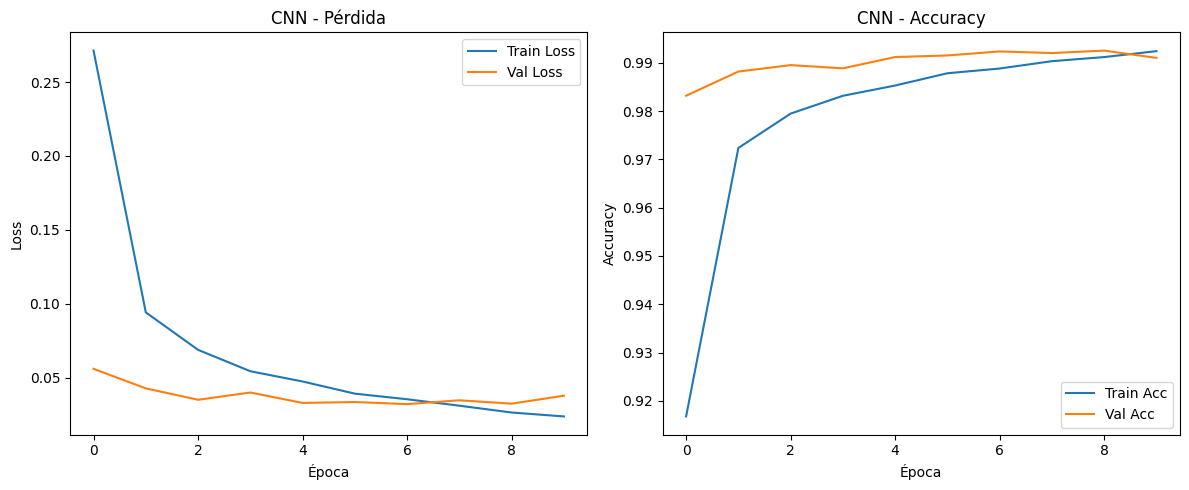

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


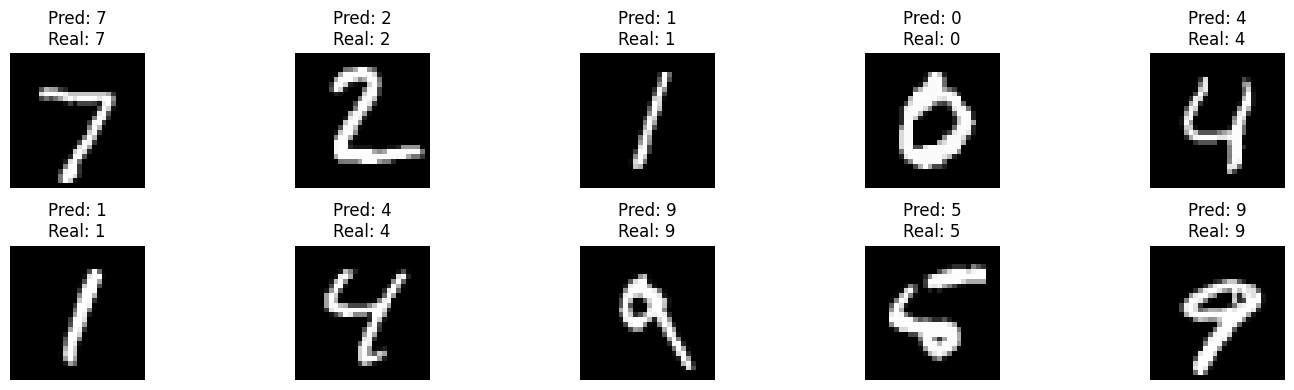

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1. Cargar y preprocesar
# =========================
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Añadir canal (28, 28, 1) y normalizar
x_train = x_train[..., tf.newaxis].astype("float32") / 255.0
x_test = x_test[..., tf.newaxis].astype("float32") / 255.0

# =========================
# 2. Construir modelo CNN
# =========================
model_cnn = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation="softmax")
])

model_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# =========================
# 3. Entrenar
# =========================
history_cnn = model_cnn.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

# =========================
# 4. Evaluar en test
# =========================
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(x_test, y_test, verbose=0)
print(f"\nCNN - Accuracy en test: {test_acc_cnn:.4f}")

# =========================
# 5. Gráficas de pérdida y accuracy
# =========================
plt.figure(figsize=(12, 5))

# Pérdida
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history["loss"], label="Train Loss")
plt.plot(history_cnn.history["val_loss"], label="Val Loss")
plt.title("CNN - Pérdida")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history["accuracy"], label="Train Acc")
plt.plot(history_cnn.history["val_accuracy"], label="Val Acc")
plt.title("CNN - Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# =========================
# 6. Predicciones de ejemplo
# =========================
preds_cnn = model_cnn.predict(x_test)
pred_labels_cnn = np.argmax(preds_cnn, axis=1)

# Mostrar 10 ejemplos
plt.figure(figsize=(15, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i, ..., 0], cmap="gray")  # quitar canal para mostrar
    plt.title(f"Pred: {pred_labels_cnn[i]}\nReal: {y_test[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()